In [1]:
import argparse
import os
import numpy as np
from Bio import Phylo
import sys
import os
import copy
import math
import json
import pandas as pd
import matplotlib.pyplot as plt

# Add parent directory to sys.path
sys.path.append(os.path.abspath(".."))
from simulation_utils import *




def read_interaction_matrix(csv_file, host_tree_file, virus_tree_file):
    """
    Read host-virus interaction matrix CSV and reorder according to tree leaves.
    Treat viruses as parasites.
    
    Returns:
        cell_state: dict with keys (virus, host) -> 0/1
        host_tree: Bio.Phylo tree object
        virus_tree: Bio.Phylo tree object
    """

    # Load trees
    host_tree = Phylo.read(host_tree_file, "newick")
    virus_tree = Phylo.read(virus_tree_file, "newick")

    # Get leaf order
    host_order = [t.name for t in host_tree.get_terminals()]
    virus_order = [t.name for t in virus_tree.get_terminals()]

    print(f"Number of hosts in tree: {len(host_order)}")
    print(f"Number of viruses in tree: {len(virus_order)}")

    # Load interaction matrix CSV
    df = pd.read_csv(csv_file, index_col=0)  # assuming rows=viruses, columns=hosts
    # Ensure names match the expected tree leaf names
    df = df.loc[df.index.intersection(virus_order), df.columns.intersection(host_order)]

    # Reorder according to tree leaves
    df = df.reindex(index=virus_order, columns=host_order, fill_value=0)

    # Build cell_state dictionary
    cell_state = {}
    for virus in virus_order:
        for host in host_order:
            cell_state[(virus, host)] = int(df.at[virus, host])

    return cell_state, host_tree, virus_tree






def matrix_builder(out, r01_h, r10_h, r01_p, r10_p):
    # Build weight matrices for each parasite’s host tree
    host_W_matrices = []
    for t in out["host_trees"]:
        W, nodes = build_weight_matrix(t, r01_h, r10_h)
        host_W_matrices.append((W, nodes))

    # Build weight matrices for each host’s parasite tree
    par_W_matrices = []
    for t in out["par_trees"]:
        W, nodes = build_weight_matrix(t, r01_p, r10_p)
        par_W_matrices.append((W, nodes))

    # Flip cost matrix
    flip_cost_matrix = build_flip_cost_matrix(len(out["par_leaves"]), len(out["host_leaves"]), cost=1.0)
    return host_W_matrices, par_W_matrices, flip_cost_matrix


In [2]:
outdir = "experiments"
association_csv = "interaction_matrix_tree_leaves_new.csv"
host_tree = "virion_bat_cov_output/trees/hosts_tree.newick"
virus_tree = "virion_bat_cov_output/trees/viruses_tree.newick"


os.makedirs(outdir, exist_ok=True)

# Read associations + trees
cell_state, base_host_tree, base_par_tree = read_interaction_matrix(
    association_csv, host_tree, virus_tree
)

base_host_tree = rescale_tree(base_host_tree)
base_par_tree = rescale_tree(base_par_tree)

host_leaves = [t.name for t in base_host_tree.get_terminals()]
par_leaves = [t.name for t in base_par_tree.get_terminals()]

out = {
    "host_trees": [copy.deepcopy(base_host_tree) for _ in range(len(par_leaves))],
    "par_trees": [copy.deepcopy(base_par_tree) for _ in range(len(host_leaves))],
    "cell_state": cell_state,
    "host_leaves": host_leaves,
    "par_leaves": par_leaves
}

# Build the matrix
mat, parasites, hosts = get_interaction_matrix(out)

# Save the matrix visualization
plot_matrix(mat, parasites, hosts, filename=os.path.join(outdir, "original_matrix.png"))







Number of hosts in tree: 231
Number of viruses in tree: 79
Matrix saved as experiments/original_matrix.png


In [3]:
out_original = out.copy()  # Keep original for each run

In [36]:
out = out_original.copy()  # Reset to original each time
corrupt = 0
seed = 42
r01_p, r10_p, r01_h, r10_h = 0.7,0.7, 0.3, 0.3
# lambda_param = 0.9
lambda_param = 0.90  # IGNORE
host_W_matrices, par_W_matrices, flip_cost_matrix = matrix_builder(out, r01_h, r10_h, r01_p, r10_p)

In [37]:

hidden_cells = []
cut_result = solve_network_cut(
    out, host_W_matrices=host_W_matrices, par_W_matrices=par_W_matrices,
    flip_cost_matrix=flip_cost_matrix,
    lambda_param=lambda_param)
    
# ---------------------------
# Step 2: Run network cut recovery on corrupted input
# ---------------------------


new_mat = cut_result["new_matrix"]
new_cell_state = cut_result["new_cell_state"]
flips = cut_result["flips"]

highlight_flipped = {"flipped": [(p, h) for p, h, old, new in flips]}
print(f"Number of flips performed: {len(flips)}")
for p, h, old, new in flips:
    print(f"Cell ({p},{h}): {old} -> {new}")

# ---------------------------
# Step 3: Save recovered matrix with algorithm flips
# ---------------------------
# plot_matrix(new_mat, parasites, hosts,
#             filename=os.path.join(outdir, "flipped_matrix.png"),
#             highlight=highlight_flipped)






# inside main(), after you have flips and hidden_cells
# metrics = compute_metrics(hidden_cells, flips)
# print("Metrics:", metrics)






Number of flips performed: 149
Cell (virus_2691588,host_187007): 0 -> 1
Cell (virus_3433780,host_9433): 0 -> 1
Cell (virus_3119327,host_187007): 0 -> 1
Cell (virus_3119327,host_9433): 0 -> 1
Cell (virus_2809631,host_187007): 0 -> 1
Cell (virus_1335626,host_258959): 0 -> 1
Cell (virus_1335626,host_526822): 0 -> 1
Cell (virus_1335626,host_59485): 0 -> 1
Cell (virus_1508220,host_3371016): 0 -> 1
Cell (virus_1508220,host_526822): 0 -> 1
Cell (virus_3433775,host_105273): 0 -> 1
Cell (virus_3433775,host_3371014): 0 -> 1
Cell (virus_3433775,host_3371016): 0 -> 1
Cell (virus_3433775,host_3371021): 0 -> 1
Cell (virus_3433775,host_258959): 0 -> 1
Cell (virus_3433775,host_526822): 0 -> 1
Cell (virus_3433775,host_59485): 0 -> 1
Cell (virus_2832974,host_3371016): 0 -> 1
Cell (virus_2832974,host_526822): 0 -> 1
Cell (virus_2832974,host_59485): 0 -> 1
Cell (virus_1805463,host_159858): 0 -> 1
Cell (virus_1805463,host_169756): 0 -> 1
Cell (virus_1805463,host_188570): 0 -> 1
Cell (virus_1805463,host_196

In [38]:
# Load taxonomy and benchmark data
host_tax = pd.read_csv("taxonomy_host.csv", dtype=str).fillna("")
virus_tax = pd.read_csv("taxonomy_virus.csv", dtype=str).fillna("")
betacov = pd.read_csv("BinaryWebsite.csv", dtype=str).fillna("")

# Normalize text columns (case-insensitive matching)
for df in [host_tax, virus_tax, betacov]:
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].str.strip().str.lower()

# Deduplicate taxonomy files by ID
host_tax = host_tax.drop_duplicates("HostTaxID")
virus_tax = virus_tax.drop_duplicates("VirusTaxID")

# Build lookup dicts
host_lookup = dict(zip(host_tax["HostTaxID"], host_tax["Host"]))
virus_lookup = dict(zip(virus_tax["VirusTaxID"], virus_tax["VirusGenus"]))


betacov_parasites = [p for p in parasites if virus_lookup.get(p.split("_",1)[1], "") == "betacoronavirus"]

    # ----------------------------
    # Filter cols (hosts) by betacov data
    # ----------------------------
betacov_hosts_set = set(betacov["Sp"])
filtered_hosts = [h for h in hosts if host_lookup.get(h.split("_",1)[1], "") in betacov_hosts_set]



# Slice matrix
p_idx = [parasites.index(p) for p in betacov_parasites]
h_idx = [hosts.index(h) for h in filtered_hosts]
submat = mat[np.ix_(p_idx, h_idx)]
print (f"Filtered matrix size: {submat.shape} (parasites: {len(betacov_parasites)}, hosts: {len(filtered_hosts)})")



# plot_matrix(submat, betacov_parasites, filtered_hosts,
#             filename=os.path.join(outdir, "filtered_original_matrix.png"))





# Extract host sets from Ensemble column
ensemble_hosts = set(betacov.loc[betacov["Ensemble"] == "true +", "Sp"])
suspected_hosts = set(betacov.loc[betacov["Ensemble"] == "suspected", "Sp"])
negative_hosts = set(betacov.loc[betacov["Ensemble"] == "false -", "Sp"])
unlikely_hosts = set(betacov.loc[betacov["Ensemble"] == "unlikely", "Sp"])

filtered_hosts_names = [host_lookup.get(h.split("_",1)[1], "") for h in filtered_hosts]

# Overlaps with benchmark sets
true_pos_hosts  = set(filtered_hosts_names) & set(ensemble_hosts)   # correctly predicted as positive
false_pos_hosts = set(filtered_hosts_names) & set(negative_hosts)   # predicted but benchmark says negative
suspected_hits  = set(filtered_hosts_names) & set(suspected_hosts)  # predicted but benchmark says suspected
unlikely_hits   = set(filtered_hosts_names) & set(unlikely_hosts)   # predicted but benchmark says unlikely

print("Filtered hosts evaluation:")
print(f"  True +  : {len(true_pos_hosts)} ")
print(f"  False + : {len(false_pos_hosts)} ")
print(f"  Suspected: {len(suspected_hits)}")
print(f"  Unlikely : {len(unlikely_hits)} ")


# Now check flips
results = []
for virus_id, host_id, old, new in flips:   # flips = cut_result["flips"]
    v = virus_id.split("_", 1)[1]
    h = host_id.split("_", 1)[1]

    host_name = host_lookup.get(h, "")
    virus_genus = virus_lookup.get(v, "")

    if not host_name:
        status = "host_unknown"
    elif not virus_genus:
        # print (f"Warning: For Virus ID {v} Genus not found in taxonomy.")
        status = "virus_unknown"
    else:
        if virus_genus == "betacoronavirus":
            if host_name in ensemble_hosts:
                status = "correct"
            elif host_name in suspected_hosts:
                status = "incorrect_but_suspected"
            elif host_name in negative_hosts:
                status = "incorrect_but_negative"
            elif host_name in unlikely_hosts:
                status = "incorrect_but_unlikely"
            else:
                status = "host not in dataset"
        else:
            status = "non_betacoronavirus"

    results.append({
        "virus_id": v,
        "host_id": h,
        "virus_genus": virus_genus,
        "host_name": host_name,
        "status": status
    })

results_df = pd.DataFrame(results)

# Summary breakdown
#  only show correct, incorrect_but_suspected, incorrect_but_negative, incorrect_but_unlikely
results_df = results_df[results_df["status"].isin([
    "correct", "incorrect_but_suspected", "incorrect_but_negative", "incorrect_but_unlikely"
])]
print(results_df["status"].value_counts())


# --- Unique host-level summary ---
# Consider betacoronavirus predictions only
betacov_predictions = results_df[
    results_df["virus_genus"] == "betacoronavirus"
]
predicted_hosts = betacov_predictions["host_name"].unique()

# Hosts predicted as "potential bearers"
potential_statuses = ["correct","incorrect_but_negative"]
true_hosts = betacov_predictions[
    betacov_predictions["status"].isin(potential_statuses)
]["host_name"].unique()

print(f"Number of unique predicted true betacoronavirus hosts: {len(true_hosts)}")
print("Total betacoronavirus hosts predicted:", len(predicted_hosts))
print("Predicted true host set:", true_hosts)

# Save results
results_df.to_csv("flip_check_results.csv", index=False)


Filtered matrix size: (22, 187) (parasites: 22, hosts: 187)
Filtered hosts evaluation:
  True +  : 59 
  False + : 3 
  Suspected: 77
  Unlikely : 48 
status
incorrect_but_suspected    80
correct                    47
incorrect_but_negative      7
incorrect_but_unlikely      3
Name: count, dtype: int64
Number of unique predicted true betacoronavirus hosts: 12
Total betacoronavirus hosts predicted: 24
Predicted true host set: ['tylonycteris pachypus' 'vespertilio sinensis' 'rhinolophus pusillus'
 'rhinolophus monoceros' 'rhinolophus cornutus' 'rhinolophus rex'
 'rhinolophus macrotis' 'rhinolophus creaghi' 'rhinolophus thomasi'
 'rhinolophus sinicus' 'rhinolophus pearsonii' 'rhinolophus affinis']


In [7]:
betacov["Ensemble"].value_counts()

Ensemble
unlikely     666
suspected    371
true +        72
false -        7
Name: count, dtype: int64

In [8]:
host_lookup.get("178895")

'rhinolophus creaghi'

In [45]:
def plot_matrix_betacov(matrix, parasites, hosts,
                        virus_lookup, host_lookup, betacov,
                        filename="betacov_matrix.png",
                        highlight=None):
    """
    Plot flipped matrix restricted to betacoronaviruses (rows) 
    and betacov hosts (columns), with transparent column shading.
    
    0 → blue, 1 → red, flipped → green, 
    column shading: true (light green), suspected (light orange)
    """
    # ----------------------------
    # Filter rows (viruses) by betacoronavirus genus
    # ----------------------------
    betacov_parasites = [p for p in parasites if virus_lookup.get(p.split("_",1)[1], "") == "betacoronavirus"]

    # ----------------------------
    # Filter cols (hosts) by betacov data
    # ----------------------------
    betacov_hosts_set = set(betacov["Sp"])
    filtered_hosts = [h for h in hosts if host_lookup.get(h.split("_",1)[1], "") in betacov_hosts_set]

    # Slice matrix
    p_idx = [parasites.index(p) for p in betacov_parasites]
    h_idx = [hosts.index(h) for h in filtered_hosts]
    submat = matrix[np.ix_(p_idx, h_idx)]
    print (f"Filtered matrix size: {submat.shape} (parasites: {len(betacov_parasites)}, hosts: {len(filtered_hosts)})")

    
    # ----------------------------
    # Column categories
    # ----------------------------
    ensemble_hosts = set(betacov.loc[betacov["Ensemble"] == "true +", "Sp"])
    suspected_hosts = set(betacov.loc[betacov["Ensemble"] == "false -", "Sp"])

    col_categories = []
    for h in filtered_hosts:
        host_name = host_lookup.get(h.split("_",1)[1], "")
        if host_name in ensemble_hosts:
            col_categories.append("true")
        elif host_name in suspected_hosts:
            col_categories.append("false")
        else:
            col_categories.append("other")

    n_rows, n_cols = submat.shape

    # ----------------------------
    # Plot
    # ----------------------------
    fig, ax = plt.subplots(figsize=(max(6, n_cols*0.4), max(6, n_rows*0.4)))

    

    # Draw cells
    for i in range(n_rows):
        for j in range(n_cols):
            if submat[i,j] == 1:
                cell_color = "red"
            else:
                cell_color = "blue"
            ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
                                       facecolor=cell_color,
                                       edgecolor=None,
                                       linewidth=0.2,
                                       zorder=0))

    # Highlight flips
    if highlight:
        for p,h in highlight.get("flipped", []):
            if p in betacov_parasites and h in filtered_hosts:
                i = betacov_parasites.index(p)
                j = filtered_hosts.index(h)
                ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
                                           facecolor="green",
                                           edgecolor=None,
                                           linewidth=1.0,
                                           zorder=0))
    # Column background shading
    for j, cat in enumerate(col_categories):
        if cat == "true":
            color = "green"
        elif cat == "false":
            color = "orange"
        else:
            continue
        ax.add_patch(plt.Rectangle((j-0.5, -0.5), 1, n_rows, 
                                   facecolor=color, alpha=0.6, edgecolor=None, zorder=0))

    # Axes and labels
    ax.set_xlim(-0.5, n_cols-0.5)
    ax.set_ylim(n_rows-0.5, -0.5)
    ax.set_xticks(range(n_cols))
    ax.set_yticks(range(n_rows))
    ax.set_xticklabels(filtered_hosts, rotation=90, fontsize=6)
    ax.set_yticklabels(betacov_parasites, fontsize=6)

    # Grid lines
    ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
    ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    plt.title("Betacoronavirus vs Betacov Hosts (Flipped Matrix)")
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()
    print("Saved betacov-focused matrix to", filename)


Filtered matrix size: (22, 187) (parasites: 22, hosts: 187)


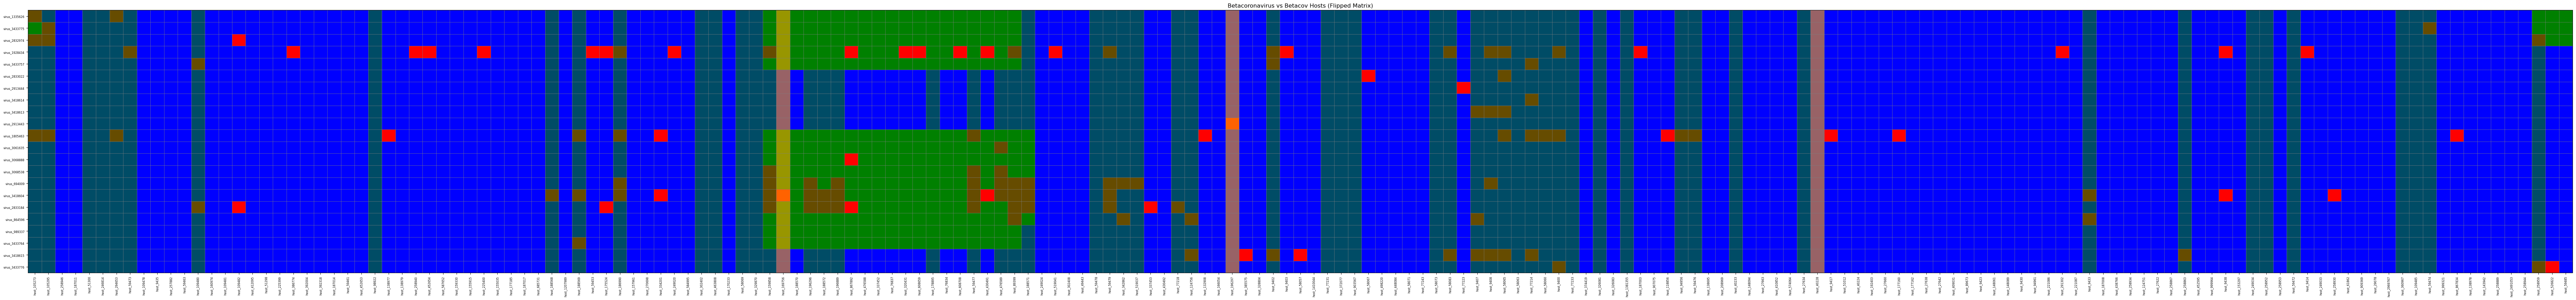

Saved betacov-focused matrix to experiments/betacov_flipped_matrix.png


In [59]:
plot_matrix_betacov(new_mat, parasites, hosts,
                    virus_lookup=virus_lookup,
                    host_lookup=host_lookup,
                    betacov=betacov,
                    filename=os.path.join(outdir, "betacov_flipped_matrix.png"),
                    highlight=highlight_flipped)

In [ ]:
cut_result = solve_network_cut(
        out, host_W_matrices=host_W_matrices, par_W_matrices=par_W_matrices,
        flip_cost_matrix=flip_cost_matrix,
        lambda_param=0.9032)
new_mat = cut_result["new_matrix"]
new_cell_state = cut_result["new_cell_state"]
flips = cut_result["flips"]

highlight_flipped = {"flipped": [(p, h) for p, h, old, new in flips]}
print(f"Number of flips performed: {len(flips)}")
for p, h, old, new in flips:
    print(f"Cell ({p},{h}): {old} -> {new}")

# ---------------------------
# Step 3: Save recovered matrix with algorithm flips
# ---------------------------
plot_matrix(new_mat, parasites, hosts,
            filename=os.path.join(outdir, "flipped_matrix.png"),
            highlight=highlight_flipped)






# inside main(), after you have flips and hidden_cells
metrics = compute_metrics(hidden_cells, flips)
print("Metrics:", metrics)

In [7]:
def smooth_scores(scores, window=5, poly=2):
    if len(scores) < window:
        return scores
    return savgol_filter(scores, window_length=window, polyorder=poly)

def parsimony_vs_flips(out, parasites, hosts, host_W_matrices, par_W_matrices,
                       flip_cost_matrix, steps, lower, upper):
    """
    Compute total parsimony and number of flips across a range of λ values.
    Returns arrays of flips, scores, and lambdas.
    """
    lambdas = np.linspace(lower, upper, steps)
    scores = []
    flips_counts = []

    for lam in lambdas:
        cut_result = solve_network_cut(
            out, host_W_matrices=host_W_matrices, par_W_matrices=par_W_matrices,
            flip_cost_matrix=flip_cost_matrix,
            lambda_param=lam
        )

        # Count flips
        flips_counts.append(len(cut_result["flips"]))

        # total parsimony across parasite×host
        total = 0
        for p in parasites:
            leaf_states = {h: cut_result["new_cell_state"][(p,h)] for h in hosts}
            total += sankoff(out["host_trees"][0], leaf_states, np.array([[0,1],[1,0]]))
        for h in hosts:
            leaf_states = {p: cut_result["new_cell_state"][(p,h)] for p in parasites}
            total += sankoff(out["par_trees"][0], leaf_states, np.array([[0,1],[1,0]]))

        scores.append(total)

    return np.array(flips_counts), np.array(scores), np.array(lambdas)


def find_elbow_parsimony_flips(out, parasites, hosts, host_W_matrices,
                               par_W_matrices, flip_cost_matrix,
                               lower, upper, steps=50, outdir="experiments"):
    # Run sweep
    flips, scores, lambdas = parsimony_vs_flips(
        out, parasites, hosts, host_W_matrices, par_W_matrices,
        flip_cost_matrix, steps=steps, lower=lower, upper=upper
    )

    # Smooth scores
    smooth = smooth_scores(scores, window=3, poly=2)

    # Elbow detection in flip-space
    kneedle = KneeLocator(
        flips, smooth,
        curve="convex", direction="decreasing"
    )
    elbow_flip = kneedle.knee
    if elbow_flip is not None:
        # Find closest λ to the elbow flip
        idx = (np.abs(flips - elbow_flip)).argmin()
        elbow_lambda = lambdas[idx]
    else:
        elbow_flip, elbow_lambda = None, None

    print(f"[Elbow detection] flip ≈ {elbow_flip}, λ ≈ {elbow_lambda}")

    # Plot
    plt.figure(figsize=(7,5))
    plt.plot(flips, scores, "bo-", label="Parsimony vs flips")
    if elbow_flip is not None:
        plt.axvline(elbow_flip, color="red", linestyle="--",
                    label=f"Elbow flip={elbow_flip}, λ≈{elbow_lambda:.3f}")
    # Annotate points with λ
    for f, s, lam in zip(flips, scores, lambdas):
        plt.text(f, s, f"{lam:.2f}", fontsize=6, ha="right", va="bottom", rotation=45)

    plt.xlabel("Number of flips")
    plt.ylabel("Parsimony")
    plt.title("Parsimony vs Flips (λ sweep)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, "parsimony_vs_flips_elbow.png"))
    plt.close()

    return elbow_flip, elbow_lambda, flips, scores, lambdas

In [8]:
elbow_flip, elbow_lambda, flips, scores, lambdas = find_elbow_parsimony_flips(
    out, parasites, hosts, host_W_matrices, par_W_matrices, flip_cost_matrix, lower=0, upper=1, steps=100, outdir=outdir
)

[Elbow detection] flip ≈ 1974, λ ≈ 0.9393939393939394


In [39]:


cut_result_elbow = solve_network_cut(
    out, host_W_matrices=host_W_matrices, par_W_matrices=par_W_matrices,
    flip_cost_matrix=flip_cost_matrix,
    lambda_param=elbow_lambda
)
flips_elbow = cut_result_elbow["flips"]

highlight_flipped = {"flipped": [(p, h) for p, h, old, new in flips_elbow]}
print(f"Number of flips performed (elbow): {len(flips_elbow)}")
# for p, h, old, new in flips_elbow:
#     print(f"Cell ({p},{h}): {old} -> {new}")
plot_matrix(cut_result_elbow["new_matrix"], parasites, hosts,
            filename=os.path.join(outdir, "flipped_matrix_elbow.png"),
            highlight=highlight_flipped)

metrics_elbow = compute_metrics(hidden_cells, flips_elbow)
print("Elbow Metrics:", metrics_elbow)

Number of flips performed (elbow): 1991
Matrix saved as experiments/flipped_matrix_elbow.png
Elbow Metrics: {'precision': 0.0, 'recall': 0, 'f1': 0, 'TP': 0, 'FP': 1991, 'FN': 0}
